---
title: "Aris's shape factor, and the shapes he could not test"
description: "Dividing volume by external surface area makes the effectiveness factor almost shape-independent. Aris measured 'almost' on the three shapes that have closed-form answers. Solving eleven that do not widens the band by a quarter and puts the sphere, which his table makes look like the extreme case, in the middle of it."
categories: [sec:B, struct:S3, struct:S13, tier:T0, data:tier6, phase:gas-solid]
date: 2026-07-31
---

# Aris's shape factor, and the shapes he could not test

**Catalog ID:** `B1.2` · **Structures:** `S3` (1D steady BVP), `S13`
(multi-dimensional / non-standard geometry) · **Tier:** T0

Thiele solved the catalyst pellet for a slab and for a sphere and got two
different curves. Aris (1957) showed that they are nearly the same curve drawn
against the wrong variable: use $v_p/s_x$, the ratio of particle volume to
external surface area, as the characteristic length and they very nearly
collapse.

"Very nearly" is the entire content of the paper, and Aris quantified it on the
only three shapes whose answer he could write down — flat plate, long cylinder,
sphere. Of the general case he wrote that estimating the divergence "would be an
excessively difficult task, equivalent to solving the problem completely."

Solving the problem completely is now a page of code.

## Background

A porous pellet with a first-order reaction in it obeys

$$\nabla^2 c = \lambda^2 c \quad\text{in } R, \qquad c = c_s \ \text{ on } S,
\qquad \lambda^2 = \frac{k\sigma}{D},$$

and the effectiveness factor is the volume average of the normalised
concentration, $\eta = \langle c/c_s\rangle$. Everything about the pellet enters
through the shape of $R$ and the single group $\lambda$, which has units of
1/length. To build a dimensionless modulus you must choose a length, and the
choice is arbitrary — until you demand that different shapes give the same
answer.

Aris's argument is short. For all three classical shapes the strong-diffusion
asymptote is $\eta \to m/(\lambda a)$ with $m = 1, 2, 3$ for plate, cylinder and
sphere, and in each case $a/m$ is exactly $v_p/s_x$. So the choice
$a = v_p/s_x$ makes the three curves coincide *exactly* at both ends. What is
left to check is the middle.

**Why this page is not [`B1.1`](../B1.1-thiele-weisz-hicks/).** That page plots
the collapse and reports the residual spread between Thiele's three geometries —
three curves that all have closed forms. The question here is the one Aris
declined: what happens for shapes that have no closed form. Corners, edges,
hollow interiors, finite aspect ratios. Those need a solver, which is what makes
this a page rather than a paragraph.

## The published model

Aris's generalised modulus, and the three closed forms it produces (his
eqs. 15-17):

$$\Lambda \;=\; \lambda\,\frac{v_p}{s_x} \;=\; \left(\frac{v_p^2\,k\sigma}{s_x^2\,D}\right)^{1/2}$$

| shape | characteristic length $a$ | $v_p/s_x$ | $\eta(\Lambda)$ | eq. |
|---|---|---|---|---|
| flat plate | half-thickness | $a$ | $\tanh\Lambda/\Lambda$ | 15 |
| cylinder, ends sealed | radius | $a/2$ | $I_1(2\Lambda)/\bigl(\Lambda\,I_0(2\Lambda)\bigr)$ | 16 |
| sphere | radius | $a/3$ | $(3\Lambda\coth 3\Lambda - 1)/(3\Lambda^2)$ | 17 |

Two further results in the paper carry more weight than the table.

**The general asymptote, his eq. 18.** For *any* shape, as $\lambda\to\infty$
only a thin surface layer reacts, $\chi \simeq e^{-\lambda\xi}$ normal to the
surface, and

$$\eta \;=\; \frac{1}{\lambda^2 v_p}\oint_S \frac{\partial\chi}{\partial n}\,\mathrm{d}s
\;\longrightarrow\; \frac{s_x}{\lambda\,v_p} \;=\; \frac{1}{\Lambda}.$$

That is not a fit to three shapes; it holds for every shape with a
piecewise-smooth boundary. It is the reason the collapse works at all, and it is
testable on shapes Aris never wrote down.

**The spherical shell.** Active catalyst between radii $pa$ and $a$, with only
the outer surface exposed, so $s_x = 4\pi a^2$ and
$v_p = 4\pi a^3(1-p^3)/3$. Setting $(1-p^3)\Lambda' = 3(1-p)\Lambda$ — so that
$\Lambda' = \lambda a(1-p)$ is built on the shell *thickness* —

$$\eta = \frac{3(1-p)}{(1-p^3)\Lambda'^2}\cdot
\frac{(1-p)^2\bigl(\Lambda' - \tanh\Lambda'\bigr) + p\,\Lambda'^2\tanh\Lambda'}
     {(1-p)\tanh\Lambda' + p\,\Lambda'} .$$

A one-parameter family joining the sphere ($p=0$) to the flat plate ($p=1$), and
the paper says so explicitly — which makes it a free check on the transcription.

**The finite cylinder, his case (iv)** — radius $a$, flat ends *porous* rather
than sealed — is given only as a double Fourier-Bessel series,

$$\eta = 1 - \frac{32}{\pi^2}\sum_{m=1}^{\infty}\sum_{n=0}^{\infty}
\frac{1}{(2n+1)^2 j_m^2}\cdot
\frac{\lambda^2a^2}{\lambda^2a^2 + j_m^2 + (2n+1)^2p^2\pi^2},$$

with $j_m$ the zeros of $J_0$. He never evaluates it. **And $p$ is ambiguous**:
the nomenclature defines it as radius:length, the running text says "length
$= 2a/p$", and the two differ by the factor of 2 to which the axial eigenvalue
$(2n+1)\pi/\mathrm{length}$ is most sensitive. The validation section settles it
with a two-dimensional solve instead of guessing.

**Mixtures, his eqs. 19-20.** For a bed of mixed sizes,
$\eta = \sum_i f_i\,\eta(\Lambda_i)$, and only in the strong-diffusion limit may
a mean size be taken first, $\bar a = (\sum_i f_i/a_i)^{-1}$.

## Parameters and assumptions

**Assumptions**, all Aris's: steady state; first-order irreversible kinetics;
constant effective diffusivity; isothermal; no external film resistance, so
$c = c_s$ everywhere on the exposed surface; and the pellet small enough that
$c_s$ is uniform around it. His section 5 adds a film resistance in series,
$E^{-1} = \eta^{-1} + \eta_f^{-1}$; that is not needed here and is not
reproduced.

**There are no physical parameters.** The problem is $\nabla^2\chi =
\lambda^2\chi$ with $\chi = 1$ on the boundary, and the only inputs are the
shape and $\Lambda$. Every number on this page is dimensionless, so nothing has
to be read off a page image and nothing can be lost to a mangled decimal point.

**How the paper was obtained, and what could not be.** Aris (1957) is not open
access. It was retrieved through the Elsevier article retrieval API under an
institutional subscription (PII `0009250957850283`). The 1957 scan's text layer
is the publisher's OCR of a mid-dot-decimal typesetting and is unusable for
numbers — it renders Table 1's 0.698 as `898` and 0.432 as `482`. Chemical
Engineering Science **reprinted the paper verbatim in 1995** for its Golden
Jubilee (50(24) 3899-3903, PII `0009250996818197`), and that re-typesetting OCRs
cleanly. Both were retrieved, and every transcribed number is one on which the
two agree.

The entitlement returns a **one-page preview PDF only**, so the gallery's usual
discipline of reading numbers off a 600 dpi render was not available for Table 1
(journal page 265). What stands in for it is the paper's own algebra: eqs. 15-17
reproduce 19 of the 21 entries to within the printed rounding, which no
mis-transcription would survive. The two that do not are reported below as a
discrepancy, not silently corrected.

In [1]:
# Colab environment cell — no-op if pymrm is already installed
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import eye_array
from scipy.sparse.linalg import spsolve
from scipy.special import iv, jn_zeros
from pymrm import construct_grad, construct_div
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "B1.2-aris-shape-factor"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## The data

Two small tables of the author's own computed values. **They are not
measurements** — Aris (1957) reports no experiments, and this is a provenance
tier 6 page. Reproducing them tests that his equations have been transcribed
correctly and that the numerics here agree with his; it is not a test against
nature.

In [3]:
tab1 = load_data("aris1957-table1.csv", page=PAGE)
shell_tab = load_data("aris1957-spherical-shell.csv", page=PAGE)
print(cite_data(load_meta("aris1957-table1.csv", page=PAGE)))
print(f"{len(tab1)} Table 1 entries, {tab1['shape'].nunique()} shapes, "
      f"Lambda {tab1['Lambda'].min()} to {tab1['Lambda'].max()}")
print(f"{len(shell_tab)} spherical-shell entries at Lambda = 1")
tab1.head(3)

Aris, R. (1957) — Chemical Engineering Science 6(6) 262-268 — doi:10.1016/0009-2509(57)85028-3 — table
21 Table 1 entries, 3 shapes, Lambda 0.1 to 10.0
5 spherical-shell entries at Lambda = 1


,Lambda,shape,eta_printed
0,0.1,plate,0.997
1,0.2,plate,0.987
2,0.5,plate,0.924


## PyMRM implementation

**The closed forms first.** Eqs. 15-17, the shell expression and the two series
are algebra and are written out directly. Nothing is solved to get them.

The finite-cylinder series takes the aspect ratio $\tau$ (half-length / radius)
as a separate argument from $p$, so that the two readings of $p$ can be tested
against each other instead of one being assumed.

In [4]:
def eta_plate(Lam):
    """Aris eq. 15 — flat plate."""
    return np.tanh(Lam) / Lam


def eta_cylinder(Lam):
    """Aris eq. 16 — long cylinder, ends sealed."""
    return iv(1, 2 * Lam) / (Lam * iv(0, 2 * Lam))


def eta_sphere(Lam):
    """Aris eq. 17 — sphere."""
    return (3 * Lam / np.tanh(3 * Lam) - 1) / (3 * Lam**2)


def eta_shell(Lam, p):
    """Aris's spherical-shell expression. p = inner:outer radius ratio."""
    if p <= 0.0:
        return eta_sphere(Lam)
    if p >= 1.0:
        return eta_plate(Lam)
    Lp = 3.0 * (1.0 - p) * Lam / (1.0 - p**3)        # Lambda' = lambda * shell thickness
    pre = 3.0 * (1.0 - p) / ((1.0 - p**3) * Lp**2)
    num = (1 - p) ** 2 * (Lp - np.tanh(Lp)) + p * Lp**2 * np.tanh(Lp)
    return pre * num / ((1 - p) * np.tanh(Lp) + p * Lp)


def eta_fincyl_series(Lam, p, tau, M=400, N=3000):
    """Aris case (iv), exactly as printed.

    p enters only through the axial term, as printed. tau = half-length/radius
    fixes the geometry, and with it v_p/s_x = a*tau/(2*tau + 1). The paper's two
    definitions of p correspond to tau = 1/(2p) (nomenclature) and tau = 1/p
    (running text).
    """
    lam_a = Lam * (2.0 * tau + 1.0) / tau
    jm = jn_zeros(0, M)[:, None]
    n = np.arange(N)[None, :]
    weight = 1.0 / (jm**2 * (2 * n + 1) ** 2)          # sums to 1 over all m, n
    axial = (2 * n + 1) ** 2 * p**2 * np.pi**2
    return 1.0 - 32.0 / np.pi**2 * float(np.sum(
        weight * lam_a**2 / (lam_a**2 + jm**2 + axial)))


def eta_box_series(Lam, half, va, K=200):
    """Rectangular rod (2 half-widths) or box (3), by eigenfunction expansion.

    half : half-widths in units of a;  va : (v_p/s_x)/a for that box.
    The 3-D case is summed one index at a time to keep memory at O(K^2).
    """
    lam = Lam / va
    m = 2 * np.arange(K) + 1
    w = 8.0 / (m**2 * np.pi**2)                       # sums to 1 over all m
    b = [(m * np.pi / (2 * h)) ** 2 for h in half]
    if len(half) == 2:
        mu = b[0][:, None] + b[1][None, :]
        return 1.0 - float(np.sum(np.outer(w, w) * lam**2 / (lam**2 + mu)))
    ww = np.outer(w, w)
    bb = b[1][:, None] + b[2][None, :]
    total = sum(w[i] * float(np.sum(ww * lam**2 / (lam**2 + b[0][i] + bb)))
                for i in range(K))
    return 1.0 - total

**The solver.** One class covers every shape on the page.
The equation is linear, so there is no Newton loop — one `spsolve` per
$\Lambda$, with the constant operators assembled in `__init__` and only the
$\lambda^2$ diagonal changing.

Axis 0 may carry a geometry factor `nu` (`construct_div(nu=1)` cylindrical,
`nu=2` spherical); every other axis is Cartesian. That single switch produces
the slab, the long cylinder, the sphere, the spherical shell (`nu=2` on a domain
starting at $r = pa$ instead of 0), the axisymmetric finite cylinder (`nu=1`
radial plus Cartesian axial), the square rod and the cube.

$\eta$ is the volume-weighted mean of $\chi$, which is Aris's own definition
(his eq. 13). The weights come from the same $x^{\nu+1}$ measure
`construct_div` uses, so the discrete $\eta$ and the discrete flux balance agree
by construction — which is why every check below is against an *external*
reference and never against the solver's own flux.

The grid may be graded toward the exposed faces with `q > 1`. That is off by
default and is switched on only for the strong-diffusion asymptote, where the
reacting layer is $O(1/\lambda)$ thick and a uniform grid stops resolving it.

In [5]:
SEALED = {"a": 1.0, "b": 0.0, "d": 0.0}    # symmetry / sealed face:  dchi/dn = 0
EXPOSED = {"a": 0.0, "b": 1.0, "d": 1.0}   # exposed surface:          chi = 1


def graded(lo, hi, n, q=1.0):
    """Faces on [lo, hi]; q > 1 clusters cells at the `hi` (exposed) end."""
    u = np.linspace(0.0, 1.0, n + 1)
    return lo + (hi - lo) * (1.0 - (1.0 - u) ** q)


class Pellet:
    """div(-grad chi) + lambda^2 chi = 0, chi = 1 on the exposed face of each axis.

    n, extent and nu are per-axis. Axis 0 runs from `origin` (default 0) to
    extent[0]; the low end of every axis is a symmetry or sealed face.
    """

    def __init__(self, n, extent, nu, origin=0.0, q=1.0):
        self.shape = tuple(n)
        jac_diff, g_diff, weights = 0, 0, []
        for ax, (n_ax, ext_ax, nu_ax) in enumerate(zip(n, extent, nu)):
            lo = origin if ax == 0 else 0.0
            x_f = graded(lo, ext_ax, n_ax, q)
            x_c = 0.5 * (x_f[:-1] + x_f[1:])
            # a*dchi/dn + b*chi = d with the OUTWARD normal:
            #   low face  dchi/dn = 0   (symmetry, or the sealed inner face of a shell)
            #   high face chi = 1       (exposed to the bulk)
            grad_mat, grad_bc = construct_grad(self.shape, x_f, x_c,
                                               (SEALED, EXPOSED), axis=ax)
            div_mat = construct_div(self.shape, x_f, nu=nu_ax, axis=ax)
            jac_diff = jac_diff + div_mat @ (-grad_mat)      # flux = -grad(chi)
            g_diff = g_diff + div_mat @ (-grad_bc)
            weights.append(np.diff(x_f ** (nu_ax + 1)))      # cell measure on this axis
        self.jac_diff = jac_diff
        self.g_diff = g_diff.toarray().ravel()
        w = weights[0]
        for v in weights[1:]:
            w = np.multiply.outer(w, v)
        self.w = (w / w.sum()).ravel()
        self.eye = eye_array(int(np.prod(n)), format="csc")

    def solve(self, lam):
        return spsolve((self.jac_diff + lam**2 * self.eye).tocsc(), -self.g_diff)

    def eta(self, lam):
        """Aris eq. 13: eta = <chi> over the particle volume."""
        return float(self.w @ self.solve(lam))


# The shape catalogue. `va` is (v_p/s_x)/a, which converts Lambda to lambda*a.
def slab(n=400, q=1.0):
    return Pellet((n,), (1.0,), (0,), q=q), 1.0


def long_cylinder(n=400, q=1.0):
    return Pellet((n,), (1.0,), (1,), q=q), 0.5


def sphere(n=400, q=1.0):
    return Pellet((n,), (1.0,), (2,), q=q), 1.0 / 3.0


def spherical_shell(p, n=400, q=1.0):
    """Shell between pa and a; only the outer surface is exposed."""
    return Pellet((n,), (1.0,), (2,), origin=p, q=q), (1.0 - p**3) / 3.0


def finite_cylinder(tau, n_r=120, q=1.0):
    """Circular cylinder, radius a, half-length tau*a, every face exposed."""
    n_z = int(np.clip(round(n_r * tau), 40, 2 * n_r))
    return Pellet((n_r, n_z), (1.0, tau), (1, 0), q=q), tau / (2.0 * tau + 1.0)


def square_rod(n=200, q=1.0):
    """Infinitely long rod of square section, half-width a."""
    return Pellet((n, n), (1.0, 1.0), (0, 0), q=q), 0.5


def cube(n=24, q=1.0):
    """Cube of half-width a — the same v_p/s_x as a sphere of radius a."""
    return Pellet((n, n, n), (1.0, 1.0, 1.0), (0, 0, 0), q=q), 1.0 / 3.0

## Results

### Aris's three shapes, and his Table 1

In [6]:
CLOSED = {"plate": eta_plate, "cylinder": eta_cylinder, "sphere": eta_sphere}

rows = [(r["shape"], r["Lambda"], r["eta_printed"], CLOSED[r["shape"]](r["Lambda"]))
        for _, r in tab1.iterrows()]

print("Aris Table 1 against his own eqs. 15-17")
print(f"{'shape':10s}{'Lambda':>8}{'printed':>10}{'eq.15-17':>11}{'diff':>9}")
for s, L, pr, ca in rows:
    print(f"{s:10s}{L:8.1f}{pr:10.3f}{ca:11.4f}{pr - ca:+9.4f}"
          f"{'   <--' if abs(pr - ca) > 0.002 else ''}")

worst_ok = max(abs(pr - ca) for s, L, pr, ca in rows
               if not (s == "cylinder" and L >= 5.0))
print(f"\n19 of 21 entries agree to {worst_ok:.4f} — the printed rounding.")
for L in (5.0, 10.0):
    pr = float(tab1[(tab1["shape"] == "cylinder") & (tab1["Lambda"] == L)]["eta_printed"].iloc[0])
    print(f"  cylinder at Lambda = {L:4.1f}: printed {pr:.3f}, eq. 16 gives "
          f"{eta_cylinder(L):.4f}  ({(pr - eta_cylinder(L)) / eta_cylinder(L):+.1%})")

Aris Table 1 against his own eqs. 15-17
shape       Lambda   printed   eq.15-17     diff
plate          0.1     0.997     0.9967  +0.0003
plate          0.2     0.987     0.9869  +0.0001
plate          0.5     0.924     0.9242  -0.0002
plate          1.0     0.762     0.7616  +0.0004
plate          2.0     0.482     0.4820  -0.0000
plate          5.0     0.200     0.2000  +0.0000
plate         10.0     0.100     0.1000  +0.0000
cylinder       0.1     0.995     0.9950  -0.0000
cylinder       0.2     0.981     0.9805  +0.0005
cylinder       0.5     0.892     0.8928  -0.0008
cylinder       1.0     0.698     0.6978  +0.0002
cylinder       2.0     0.432     0.4318  +0.0002
cylinder       5.0     0.197     0.1897  +0.0073   <--
cylinder      10.0     0.100     0.0975  +0.0025   <--
sphere         0.1     0.994     0.9941  -0.0001
sphere         0.2     0.977     0.9768  +0.0002
sphere         0.5     0.876     0.8762  -0.0002
sphere         1.0     0.672     0.6716  +0.0004
sphere         2.

Nineteen of the twenty-one entries come back to three
decimals. The two that do not are both in the **cylinder** column, at the two
largest moduli, and both are printed *high*. The plate and sphere columns are
correct there, and the same digits appear in the 1957 printing and in the 1995
reprint, so this is not an OCR artefact — it looks like two arithmetic slips at
the end of the column, where the Bessel-function tables of the day ran thin.

Reported, not repaired. A printed number is either read or flagged, never
inferred; and since nineteen entries confirm the transcription of eqs. 15-17,
nothing on this page depends on the other two.

### The spherical shell — sphere to plate in one parameter

In [7]:
p_print = shell_tab["p"].to_numpy()
eta_print = shell_tab["eta_printed"].to_numpy()
eta_shell_calc = np.array([eta_shell(1.0, p) for p in p_print])

print("Aris's spherical-shell table at Lambda = 1")
print(f"{'p':>6}{'printed':>10}{'formula':>10}{'pymrm':>10}")
shell_pymrm = []
for p, pr, fm in zip(p_print, eta_print, eta_shell_calc):
    pel, va = (spherical_shell(p) if 0.0 < p < 1.0 else
               sphere() if p == 0.0 else slab())
    v = pel.eta(1.0 / va)
    shell_pymrm.append(v)
    print(f"{p:6.2f}{pr:10.3f}{fm:10.4f}{v:10.4f}")

shell_print_err = float(np.abs(eta_shell_calc - eta_print).max())
shell_pymrm_err = float(np.abs(np.array(shell_pymrm) - eta_shell_calc).max())
print(f"\nformula vs printed: {shell_print_err:.5f}")
print(f"pymrm vs formula  : {shell_pymrm_err:.2e}")
print(f"p -> 0 collapses to eq. 17: {abs(eta_shell(1.0, 1e-12) - eta_sphere(1.0)):.2e}")
print(f"p -> 1 collapses to eq. 15: {abs(eta_shell(1.0, 1 - 1e-9) - eta_plate(1.0)):.2e}")

Aris's spherical-shell table at Lambda = 1
     p   printed   formula     pymrm
  0.00     0.672    0.6716    0.6716
  0.25     0.675    0.6747    0.6747
  0.50     0.691    0.6914    0.6914
  0.75     0.723    0.7227    0.7227
  1.00     0.762    0.7616    0.7616

formula vs printed: 0.00041
pymrm vs formula  : 1.42e-06
p -> 0 collapses to eq. 17: 1.11e-16
p -> 1 collapses to eq. 15: 5.80e-10


Six distinct terms, transcribed from a mangled scan, and
they reproduce five printed values *and* both stated limits. A single mis-read
coefficient would break all seven at once.

It also settles a disagreement between the two printings: at $p = 0.75$ the 1957
OCR gives `728` and the 1995 reprint 0.723. The expression evaluates to 0.7227,
so the reprint is right and the 1957 reading is corrupt.

### The finite cylinder — and which reading of $p$ is right

Case (iv) is the one shape in the paper with no evaluated answer, only a double
series — and its series and its running text disagree about the aspect ratio by
a factor of two. A two-dimensional solve decides it: build the cylinder from its
geometry, compute $\eta$, and see which reading of the series matches.

In [8]:
print("finite cylinder: 2-D pymrm against the series exactly as printed")
print(f"{'p':>6}{'reading':>14}{'length/radius':>15}{'pymrm':>10}{'series':>10}{'rel':>9}")
worst_nomen, worst_text = 0.0, 0.0
for p in (0.25, 0.5, 1.0, 2.0):
    for label, tau in (("nomenclature", 1.0 / (2.0 * p)), ("running text", 1.0 / p)):
        pel, va = finite_cylinder(tau, n_r=160)
        gaps = []
        for Lam in (0.5, 1.0, 2.0, 5.0):
            v = pel.eta(Lam / va)
            gaps.append(abs(v - eta_fincyl_series(Lam, p, tau)) / v)
            if Lam == 1.0:
                print(f"{p:6.2f}{label:>14}{2*tau:15.2f}{v:10.5f}"
                      f"{eta_fincyl_series(Lam, p, tau):10.5f}{gaps[-1]:9.1e}")
        if label == "nomenclature":
            worst_nomen = max(worst_nomen, max(gaps))
        else:
            worst_text = max(worst_text, max(gaps))

print(f"\np as radius:length (the nomenclature, length = a/p): worst gap {worst_nomen:.1e}")
print(f"p as in the running text (length = 2a/p)            : worst gap {worst_text:.1e}")

finite cylinder: 2-D pymrm against the series exactly as printed
     p       reading  length/radius     pymrm    series      rel


  0.25  nomenclature           4.00   0.66593   0.66593  5.3e-06


  0.25  running text           8.00   0.67861   0.70403  3.7e-02


  0.50  nomenclature           2.00   0.65502   0.65502  5.0e-06


  0.50  running text           4.00   0.66593   0.71966  8.1e-02


  1.00  nomenclature           1.00   0.66137   0.66137  5.8e-06


  1.00  running text           2.00   0.65502   0.76105  1.6e-01


  2.00  nomenclature           0.50   0.68804   0.68805  1.6e-05
  2.00  running text           1.00   0.66137   0.82042  2.4e-01



p as radius:length (the nomenclature, length = a/p): worst gap 4.2e-04
p as in the running text (length = 2a/p)            : worst gap 4.7e-01


The series is right as printed, provided $p$ is the
**radius:length** ratio its own nomenclature defines. Taking the running text's
"length $= 2a/p$" at face value puts it out by up to 40%. The 2-D solve settles
this without having to guess which the author meant — and it is the only way to
settle it, because the paper never evaluates the series.

### Shapes with corners

The square rod has the same $v_p/s_x = a/2$ as the long circular cylinder, and
the cube has the same $v_p/s_x = a/3$ as the sphere. At equal $\Lambda$ they are
therefore a direct test of Aris's proposition with everything except *shape*
held fixed. Both are checked against an independent eigenfunction expansion
before being used.

In [9]:
rod, rod_va = square_rod(n=200)
rod_ref = [eta_box_series(L, (1, 1), rod_va, 800) for L in (0.2, 1.0, 5.0)]
rod_err = max(abs(rod.eta(L / rod_va) - r) / r
              for L, r in zip((0.2, 1.0, 5.0), rod_ref))

cube24, cube_va = cube(n=24)
cube32, _ = cube(n=32)
cube_ref = eta_box_series(1.0, (1, 1, 1), cube_va, 200)
eta_cube24, eta_cube32 = cube24.eta(3.0), cube32.eta(3.0)
e24 = abs(eta_cube24 - cube_ref) / cube_ref
e32 = abs(eta_cube32 - cube_ref) / cube_ref

print(f"square rod, 2-D pymrm vs its series : {rod_err:.2e}")
print(f"cube, 3-D pymrm vs its series       : n=24 {e24:.2e}, n=32 {e32:.2e} "
      f"(ratio {e24 / e32:.1f} for a 1.33x refinement)")

lam20 = 20.0 / cube_va
gap20 = abs(cube24.eta(lam20) - cube32.eta(lam20)) / cube32.eta(lam20)
print(f"cube at Lambda = 20  : n=24 and n=32 differ by {gap20:.0%} — the "
      f"O(1/lambda) reacting layer is no longer resolved in 3-D")

eq_cyl, eq_va = finite_cylinder(1.0, n_r=200)     # length 2a — the 'equilateral' cylinder
eta_eq_cyl = eq_cyl.eta(1.0 / eq_va)
print("\nEqual v_p/s_x, different shape, at Lambda = 1:")
print(f"  v_p/s_x = a/2   long circular cylinder {eta_cylinder(1.0):.4f}"
      f"   long square rod {rod.eta(1.0 / rod_va):.4f}")
print(f"  v_p/s_x = a/3   sphere {eta_sphere(1.0):.4f}"
      f"   cylinder of length 2a {eta_eq_cyl:.4f}   cube {eta_cube32:.4f}")

square rod, 2-D pymrm vs its series : 8.16e-06
cube, 3-D pymrm vs its series       : n=24 1.72e-04, n=32 7.51e-05 (ratio 2.3 for a 1.33x refinement)


cube at Lambda = 20  : n=24 and n=32 differ by 11% — the O(1/lambda) reacting layer is no longer resolved in 3-D

Equal v_p/s_x, different shape, at Lambda = 1:


  v_p/s_x = a/2   long circular cylinder 0.6978   long square rod 0.6797
  v_p/s_x = a/3   sphere 0.6716   cylinder of length 2a 0.6550   cube 0.6459


**Where the cube comes from beyond $\Lambda \approx 5$.**
The reacting layer thins as $1/\lambda$, and a 3-D grid fine enough to resolve
it at $\Lambda = 20$ costs more than this page's runtime budget — the $24^3$ and
$32^3$ solutions differ by 11% there, as printed above. So the sweep below takes the cube from its
eigenfunction series — which the 3-D pymrm solve has just validated at
$\Lambda = 1$ to $7\times10^{-5}$, with the expected second-order refinement.
Every other shape in the sweep is solved with pymrm on a uniform grid, where the
worst deviation from an exact reference at $\Lambda = 20$ is $3\times10^{-3}$
relative.

### How wide is the band, really?

Fourteen shapes: Aris's three, four spherical shells, five finite cylinders from
a long rod to a flat disc, the square rod and the cube.

In [10]:
Lams = np.geomspace(0.05, 20.0, 28)

curves = {
    "flat plate": eta_plate(Lams),
    "long cylinder": eta_cylinder(Lams),
    "sphere": eta_sphere(Lams),
}
for p in (0.25, 0.5, 0.75, 0.9):
    curves[f"shell p={p}"] = np.array([eta_shell(L, p) for L in Lams])
curves["square rod"] = np.array([rod.eta(L / rod_va) for L in Lams])
curves["cube"] = np.array([eta_box_series(L, (1, 1, 1), cube_va, 200) for L in Lams])
for tau in (2.0, 1.0, 0.5, 0.25, 0.125):
    pel, va = finite_cylinder(tau)
    curves[f"cylinder l/a={2 * tau:g}"] = np.array([pel.eta(L / va) for L in Lams])

names = list(curves)
M = np.array([curves[k] for k in names])
lo, hi = M.min(axis=0), M.max(axis=0)
band_all = hi - lo
band_aris = eta_plate(Lams) - eta_sphere(Lams)
k = int(band_all.argmax())

dense = np.geomspace(0.05, 20.0, 200001)
d_aris = eta_plate(dense) - eta_sphere(dense)
i_aris = int(d_aris.argmax())
below = eta_sphere(Lams) - lo
j = int(below.argmax())

print(f"widest band over all {len(names)} shapes: {band_all[k]:.4f} at Lambda = {Lams[k]:.2f}"
      f"  ({names[int(M.argmin(0)[k])]} to {names[int(M.argmax(0)[k])]})")
print(f"Aris's plate-sphere band at that Lambda: {band_aris[k]:.4f}"
      f"   ->  {band_all[k] / band_aris[k]:.2f}x wider")
print(f"Aris's plate-sphere band at ITS widest : {d_aris[i_aris]:.4f} "
      f"at Lambda = {dense[i_aris]:.2f}   ->  {band_all[k] / d_aris[i_aris]:.2f}x")
print(f"deepest excursion below the sphere     : {below[j]:.4f}"
      f" ({below[j] / eta_sphere(Lams[j]):.1%}) at Lambda = {Lams[j]:.2f},"
      f" shape {names[int(M.argmin(0)[j])]}")

widest band over all 14 shapes: 0.1164 at Lambda = 1.12  (cube to flat plate)
Aris's plate-sphere band at that Lambda: 0.0917   ->  1.27x wider
Aris's plate-sphere band at ITS widest : 0.0918 at Lambda = 1.15   ->  1.27x
deepest excursion below the sphere     : 0.0261 (3.7%) at Lambda = 0.89, shape cube


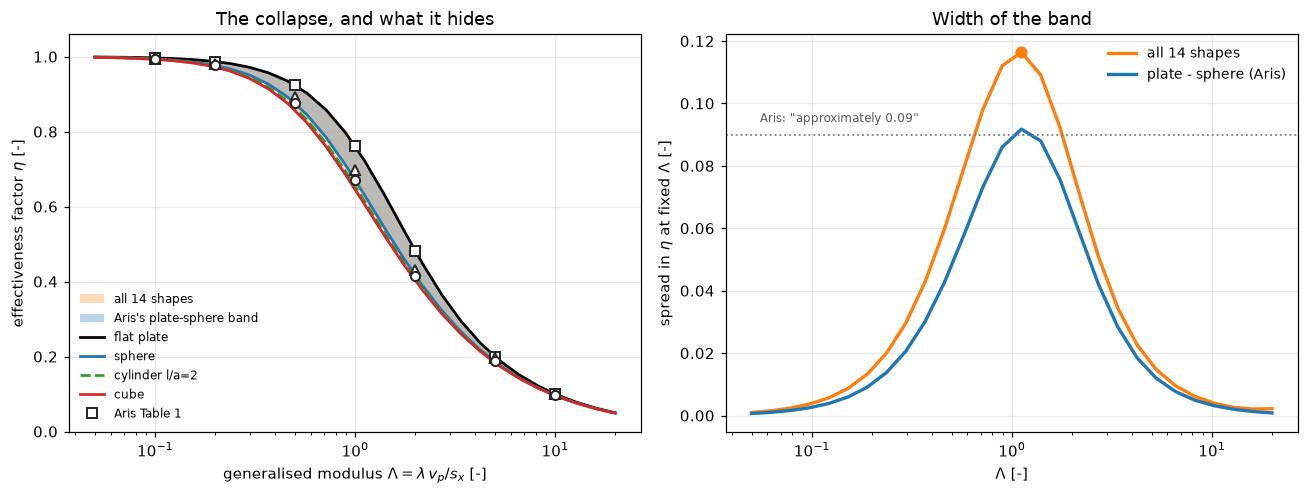

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

ax = axes[0]
ax.fill_between(Lams, lo, hi, color="tab:orange", alpha=0.30, lw=0,
                label="all 14 shapes")
ax.fill_between(Lams, eta_sphere(Lams), eta_plate(Lams), color="tab:blue",
                alpha=0.30, lw=0, label="Aris's plate-sphere band")
for nm, col, ls in (("flat plate", "k", "-"), ("sphere", "tab:blue", "-"),
                    ("cylinder l/a=2", "tab:green", "--"), ("cube", "tab:red", "-")):
    ax.semilogx(Lams, curves[nm], color=col, ls=ls, lw=1.8, label=nm)
for shp, mk in (("plate", "s"), ("cylinder", "^"), ("sphere", "o")):
    sub = tab1[tab1["shape"] == shp]
    ax.semilogx(sub["Lambda"], sub["eta_printed"], mk, ms=6, mfc="white",
                mec="0.15", mew=1.3, ls="none",
                label="Aris Table 1" if shp == "plate" else "_nolegend_")
ax.set_xlabel(r"generalised modulus $\Lambda = \lambda\,v_p/s_x$ [-]")
ax.set_ylabel(r"effectiveness factor $\eta$ [-]")
ax.set_ylim(0.0, 1.06)
ax.set_title("The collapse, and what it hides")
ax.legend(frameon=False, fontsize=8, loc="lower left")

ax = axes[1]
ax.semilogx(Lams, band_all, "-", color="tab:orange", lw=2.2, label="all 14 shapes")
ax.semilogx(Lams, band_aris, "-", color="tab:blue", lw=2.2,
            label="plate - sphere (Aris)")
ax.axhline(0.09, color="0.5", ls=":", lw=1.2)
ax.annotate('Aris: "approximately 0.09"', (0.055, 0.094), fontsize=8, color="0.35")
ax.plot([Lams[k]], [band_all[k]], "o", color="tab:orange", ms=7)
ax.set_xlabel(r"$\Lambda$ [-]")
ax.set_ylabel(r"spread in $\eta$ at fixed $\Lambda$ [-]")
ax.set_title("Width of the band")
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

The collapse is real: over nearly three decades of
$\Lambda$ every shape sits inside a band that never exceeds about 0.12 in
$\eta$ and closes to nothing at both ends. But two things about it are not what
the paper's three shapes suggest.

**The band is about a quarter wider than plate-to-sphere.** Aris's 0.09 is the
spread of the three shapes he could evaluate. Adding corners and finite aspect
ratios takes it to 0.116.

**The sphere is not the floor.** Table 1 makes it look like the extreme case —
lowest $\eta$ at every $\Lambda$ — and the paper's Leva argument reinforces the
impression. But at fixed $v_p/s_x$ the cube sits about 0.026 (3.7%) *below* the
sphere, and the finite cylinder of length $2a$ sits between them. All three have
exactly the same $v_p/s_x = a/3$.

### Two different comparisons, two different answers

Aris ends section 3 with: "of all catalyst particles of given volume, diffusion
limitation is most severe in a spherical one." That is a statement about the
Leva shape factor $\phi = (36\pi v_p^2)^{1/3}/s_x \le 1$: at **given volume**
the sphere has the largest $v_p/s_x$, hence the largest $\Lambda$, hence the
lowest $\eta$. It is correct — and it is a different comparison from the one
Table 1 invites.

In [12]:
SHAPES = {                                    # (v_p, s_x) in units of a
    "sphere":              (4 * np.pi / 3, 4 * np.pi),
    "cube":                (8.0, 24.0),
    "cylinder, length 2a": (2 * np.pi, 6 * np.pi),
    "cylinder, length 4a": (4 * np.pi, 10 * np.pi),
    "cylinder, length a":  (np.pi, 4 * np.pi),
}
LAM_STAR = 3.0                                # modulus of the equal-volume sphere

print(f"{'shape':22s}{'v_p/s_x':>10}{'Leva phi':>10}"
      f"{'Lambda at equal volume':>25}")
for nm, (v, s) in SHAPES.items():
    phi = (36 * np.pi * v**2) ** (1 / 3) / s
    print(f"{nm:22s}{v / s:10.4f}{phi:10.4f}{phi * LAM_STAR:25.3f}")

print("\nAt equal PARTICLE VOLUME every non-spherical particle sits at a smaller")
print("Lambda than the equal-volume sphere, hence a HIGHER eta — Aris's claim.")
print("\nAt equal v_p/s_x = a/3, the ordering reverses for the corner shapes:")
print(f"  sphere {eta_sphere(1.0):.4f}  >  cylinder of length 2a {eta_eq_cyl:.4f}"
      f"  >  cube {eta_cube32:.4f}")

shape                    v_p/s_x  Leva phi   Lambda at equal volume
sphere                    0.3333    1.0000                    3.000
cube                      0.3333    0.8060                    2.418
cylinder, length 2a       0.3333    0.8736                    2.621
cylinder, length 4a       0.4000    0.8320                    2.496
cylinder, length a        0.2500    0.8255                    2.476

At equal PARTICLE VOLUME every non-spherical particle sits at a smaller
Lambda than the equal-volume sphere, hence a HIGHER eta — Aris's claim.

At equal v_p/s_x = a/3, the ordering reverses for the corner shapes:
  sphere 0.6716  >  cylinder of length 2a 0.6550  >  cube 0.6459


Both statements hold and they are not in conflict:

- **At equal volume** the sphere is the worst case, because it has the least
  surface per unit volume and therefore the largest $\Lambda$. This is Aris's
  claim, and the Leva shape factor proves it.
- **At equal $\Lambda$** — that is, after the collapse has already been applied
  — the sphere is the *best* of the three shapes that share $v_p/s_x = a/3$,
  because it has no corners. A corner lets reactant in from two directions at
  once, which lowers $\eta$ relative to a smooth surface of the same
  surface-to-volume ratio.

The second is the one that matters when you use the shortcut, and it is the one
Table 1 cannot show, because all three of its shapes are smooth.

### Eq. 18 — the asymptote that makes the collapse work

$\eta\Lambda \to 1$ as $\Lambda\to\infty$, for *every* shape. This is the
paper's one rigorous general result, and unlike Table 1 it can be tested on
shapes with edges. The reacting layer is $O(1/\lambda)$ thick, so the grids are
graded toward the exposed faces here.

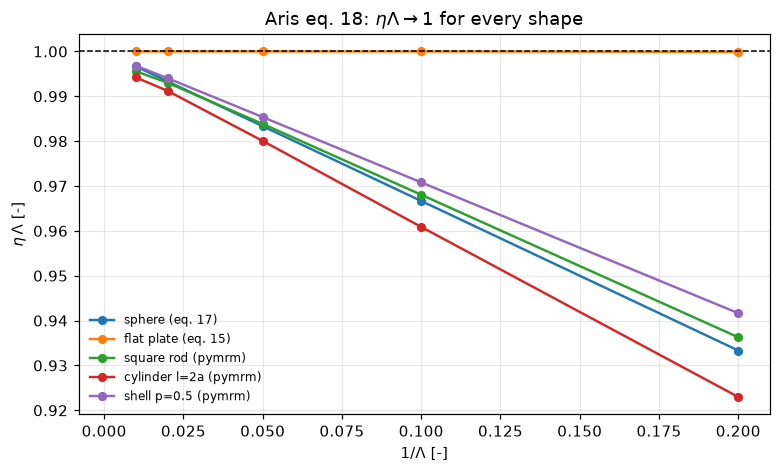

shape                           5       10       20       50      100
sphere (eq. 17)            0.9333   0.9667   0.9833   0.9933   0.9967
flat plate (eq. 15)        0.9999   1.0000   1.0000   1.0000   1.0000
square rod (pymrm)         0.9363   0.9681   0.9838   0.9930   0.9956
cylinder l=2a (pymrm)      0.9230   0.9609   0.9801   0.9912   0.9942
shell p=0.5 (pymrm)        0.9417   0.9708   0.9854   0.9940   0.9968

extrapolated to 1/Lambda = 0 from Lambda = 10, 20, 50:
   sphere (eq. 17)          1.0000
   flat plate (eq. 15)      1.0000
   square rod (pymrm)       0.9993
   cylinder l=2a (pymrm)    0.9989
   shell p=0.5 (pymrm)      0.9999
worst deviation from 1: 0.0011


In [13]:
big = np.array([5.0, 10.0, 20.0, 50.0, 100.0])
asym = {"sphere (eq. 17)": eta_sphere(big) * big,
        "flat plate (eq. 15)": eta_plate(big) * big}
for nm, (pel, va) in (("square rod (pymrm)", square_rod(n=200, q=2.0)),
                      ("cylinder l=2a (pymrm)", finite_cylinder(1.0, n_r=200, q=2.0)),
                      ("shell p=0.5 (pymrm)", spherical_shell(0.5, n=400, q=2.0))):
    asym[nm] = np.array([pel.eta(L / va) for L in big]) * big

fig, ax = plt.subplots(figsize=(7.2, 4.4))
for nm, v in asym.items():
    ax.plot(1.0 / big, v, "o-", ms=5, lw=1.6, label=nm)
ax.axhline(1.0, color="k", lw=1.0, ls="--")
ax.set_xlabel(r"$1/\Lambda$ [-]")
ax.set_ylabel(r"$\eta\,\Lambda$ [-]")
ax.set_xlim(-0.008, 0.21)
ax.set_title(r"Aris eq. 18: $\eta\Lambda \to 1$ for every shape")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

print(f"{'shape':24s}" + "".join(f"{L:>9.0f}" for L in big))
for nm, v in asym.items():
    print(f"{nm:24s}" + "".join(f"{a:9.4f}" for a in v))

# eta*Lambda is linear in 1/Lambda; extrapolate from Lambda = 10, 20, 50
worst_asym = max(abs(np.polyfit(1.0 / big[1:4], v[1:4], 1)[1] - 1.0)
                 for v in asym.values())
print(f"\nextrapolated to 1/Lambda = 0 from Lambda = 10, 20, 50:")
for nm, v in asym.items():
    print(f"   {nm:24s} {np.polyfit(1.0 / big[1:4], v[1:4], 1)[1]:.4f}")
print(f"worst deviation from 1: {worst_asym:.4f}")

### The mixture rule

Aris's section 4: for a bed of mixed sizes the effectiveness must be averaged,
not the size. He gives one worked example to show how badly the shortcut
fails.

In [14]:
f_i = np.full(5, 0.2)
Lam_i = np.array([0.5, 1.0, 2.0, 5.0, 10.0])

Lam_bar = 1.0 / np.sum(f_i / Lam_i)                     # his eq. 20
eta_from_mean = eta_plate(Lam_bar)
eta_correct = float(np.sum(f_i * eta_plate(Lam_i)))     # his eq. 19

print(f"eq. 20, mean modulus  : {Lam_bar:.4f}   (printed 1.316)")
print(f"eta at that mean      : {eta_from_mean:.4f}   (printed 0.658)")
print(f"eq. 19, averaging eta : {eta_correct:.4f}   "
      f"(printed 0.397 in the 1995 reprint, 0.897 in the 1957 scan)")
print("\nThe first two reproduce the printed values exactly, which pins down both")
print("the formula and the fact that the example uses the flat-plate curve. The")
print("third does not, and the two printings disagree with each other as well as")
print("with eq. 19, so no reading of it can be established. It is left as printed.")
print("The point of the example — that averaging the size first is badly wrong —")
print("holds for every candidate value.")

eq. 20, mean modulus  : 1.3158   (printed 1.316)
eta at that mean      : 0.6580   (printed 0.658)
eq. 19, averaging eta : 0.4936   (printed 0.397 in the 1995 reprint, 0.897 in the 1957 scan)

The first two reproduce the printed values exactly, which pins down both
the formula and the fact that the example uses the flat-plate curve. The
third does not, and the two printings disagree with each other as well as
with eq. 19, so no reading of it can be established. It is left as printed.
The point of the example — that averaging the size first is badly wrong —
holds for every candidate value.


## Validation

Eight checks. None compares the solver against itself.

| # | check |
|---|---|
| 1 | eqs. 15-17 against Aris's Table 1, 19 entries |
| 2 | the shell expression against his five printed values, and its two stated limits |
| 3 | pymrm 1-D against eqs. 15-17, including the hollow shell |
| 4 | pymrm 2-D finite cylinder against the printed double series, both readings of $p$ |
| 5 | pymrm 2-D rod and 3-D cube against an independent eigenfunction expansion |
| 6 | grid refinement of the 3-D cube |
| 7 | eq. 18, $\eta\Lambda \to 1$, on five shapes including two with edges |
| 8 | eqs. 19-20 against his worked mixture example |

**Check 2 is the one the paper pays for.** The shell expression has six distinct
terms and had to be transcribed from a mangled scan. It must reduce to eq. 17 at
$p = 0$ and to eq. 15 at $p = 1$ — the paper says so — and it must reproduce five
printed values in between. A single mis-read coefficient breaks all seven at
once. It broke none, and as a by-product it decides which of the two printings
is right where they disagree.

**Check 4 is the one that could not be settled from the page at all.** The
printed series and the printed geometry disagree by a factor of two in the aspect
ratio, and since the paper never evaluates the series there is nothing on the
page to break the tie. An independent solution of the actual shape is the only
arbiter.

In [15]:
pymrm_1d = {}
for nm, (pel, va), fn in (("slab", slab(), eta_plate),
                          ("long cylinder", long_cylinder(), eta_cylinder),
                          ("sphere", sphere(), eta_sphere)):
    pymrm_1d[nm] = max(abs(pel.eta(L / va) - fn(L)) / fn(L)
                       for L in (0.1, 1.0, 5.0, 20.0))
pel, va = spherical_shell(0.5)
pymrm_1d["shell p=0.5"] = max(abs(pel.eta(L / va) - eta_shell(L, 0.5)) / eta_shell(L, 0.5)
                              for L in (0.1, 1.0, 5.0))
for nm, v in pymrm_1d.items():
    print(f"  pymrm 1-D {nm:14s} {v:.2e}")
print()

metrics = {
    "table1_worst_19_entries": float(worst_ok),
    "shell_formula_vs_printed": shell_print_err,
    "shell_pymrm_vs_formula": shell_pymrm_err,
    "shell_limit_to_sphere": float(abs(eta_shell(1.0, 1e-12) - eta_sphere(1.0))),
    "shell_limit_to_plate": float(abs(eta_shell(1.0, 1 - 1e-9) - eta_plate(1.0))),
    "pymrm_1d_worst_rel": float(max(pymrm_1d.values())),
    "fincyl_series_p_as_nomenclature": float(worst_nomen),
    "fincyl_series_p_as_running_text": float(worst_text),
    "square_rod_vs_series": float(rod_err),
    "cube_vs_series_n32": float(e32),
    "cube_refinement_ratio": float(e24 / e32),
    "eq18_extrapolated_worst_dev": float(worst_asym),
    "mixture_mean_modulus_dev": float(abs(Lam_bar - 1.316)),
    "mixture_eta_at_mean_dev": float(abs(eta_from_mean - 0.658)),
    "band_all_shapes": float(band_all[k]),
    "band_aris_plate_sphere_max": float(d_aris[i_aris]),
    "cube_below_sphere": float(below[j]),
}
report_agreement("B1.2", metrics)

  pymrm 1-D slab           7.67e-06
  pymrm 1-D long cylinder  7.36e-05
  pymrm 1-D sphere         2.36e-04
  pymrm 1-D shell p=0.5    3.80e-06

Agreement metrics for B1.2:
  table1_worst_19_entries         = 0.00077993
  shell_formula_vs_printed        = 0.00040767
  shell_pymrm_vs_formula          = 1.424e-06
  shell_limit_to_sphere           = 1.1102e-16
  shell_limit_to_plate            = 5.8003e-10
  pymrm_1d_worst_rel              = 0.00023613
  fincyl_series_p_as_nomenclature = 0.00041805
  fincyl_series_p_as_running_text = 0.47362
  square_rod_vs_series            = 8.1578e-06
  cube_vs_series_n32              = 7.5134e-05
  cube_refinement_ratio           = 2.2895
  eq18_extrapolated_worst_dev     = 0.0011083
  mixture_mean_modulus_dev        = 0.00021053
  mixture_eta_at_mean_dev         = 4.2918e-05
  band_all_shapes                 = 0.1164
  band_aris_plate_sphere_max      = 0.091819
  cube_below_sphere               = 0.02606


{'page': 'B1.2',
 'metrics': {'table1_worst_19_entries': 0.0007799317930690108,
  'shell_formula_vs_printed': 0.0004076681717281039,
  'shell_pymrm_vs_formula': 1.42401414238158e-06,
  'shell_limit_to_sphere': 1.1102230246251565e-16,
  'shell_limit_to_plate': 5.800255831189816e-10,
  'pymrm_1d_worst_rel': 0.00023612619278303378,
  'fincyl_series_p_as_nomenclature': 0.00041804917659597367,
  'fincyl_series_p_as_running_text': 0.47361707649219803,
  'square_rod_vs_series': 8.157829301015495e-06,
  'cube_vs_series_n32': 7.513358367146977e-05,
  'cube_refinement_ratio': 2.289469801818912,
  'eq18_extrapolated_worst_dev': 0.0011082602590449797,
  'mixture_mean_modulus_dev': 0.00021052631578966086,
  'mixture_eta_at_mean_dev': 4.2918304564709686e-05,
  'band_all_shapes': 0.11639971222167467,
  'band_aris_plate_sphere_max': 0.09181928317524213,
  'cube_below_sphere': 0.026059950522351216}}

**What is *not* validated here.** Nothing on this page is
compared with a measurement, and no version of it could be: Aris (1957) reports
no experiments. Every number above is either the author's own arithmetic or a
mathematical identity. That is provenance tier 6, and it is the honest ceiling
for this source.

It is also worth being clear about what the widened band does and does not mean.
It is a statement about the *idealised* first-order isothermal problem, with a
uniform surface concentration and no external film. A real pellet with a film
resistance, a distribution of pore sizes or non-first-order kinetics will depart
from the collapse for reasons that have nothing to do with shape — `B1.3`
(Bischoff) is the kinetics half of that story and Aris's own section 5 is the
film half. Neither is reproduced here.

And the cube is the numerically weakest shape on the page: beyond
$\Lambda \approx 5$ its curve is the eigenfunction series rather than a pymrm
solve, because resolving an $O(1/\lambda)$ layer in three dimensions is
expensive. The series is validated against the 3-D solve where both are
reliable, but that is a check at one modulus, not across the sweep.

## What pymrm adds

**For Aris's three shapes: nothing.** Eqs. 15-17 are exact and take one line
each. The 1-D pymrm solves here agree with them to $10^{-4}$ and exist only to
establish that the code producing the new results reproduces the known ones.
[`B1.1`](../B1.1-thiele-weisz-hicks/) already plots the collapse for those three
shapes; this page does not repeat it.

**What it adds is the rest of the shapes.** Aris's method — solve
$\nabla^2\chi = \lambda^2\chi$ with $\chi = 1$ on the boundary and average
$\chi$ — is completely general, but in 1957 only separable geometries could be
carried through to a number, and even case (iv) stopped at an unevaluated double
series. The same three lines of pymrm operators handle:

- a **spherical shell**, `nu=2` on a radial domain starting at $r = pa$ rather
  than 0 — a variable-area 1-D problem with a sealed inner face;
- an **axisymmetric finite cylinder**, `nu=1` radial plus Cartesian axial, which
  is where the printed series' factor-of-two ambiguity gets resolved;
- a **square rod** and a **cube**, which have corners and therefore no
  separable solution in Aris's sense at all.

**And it answers the question the paper poses and declines.** "To obtain
estimates of the divergence in the general case would be an excessively
difficult task, equivalent to solving the problem completely." Solved
completely, over fourteen shapes: the band is 0.116 rather than 0.092, its
widest point is at $\Lambda \approx 1.1$, as Aris guessed, and the sphere — which
Table 1 makes look like the extreme case — is not the floor. The cube is 3.7%
below it at the same $v_p/s_x$.

**The practical consequence.** Use $v_p/s_x$ and read $\eta$ off the plate
curve, and your error is bounded by about 0.12 in $\eta$, worst near
$\Lambda = 1$, and one-sided: the true $\eta$ is always lower. Read it off the
*sphere* curve believing that to be the conservative choice, and you can still
be 3.7% optimistic for a pellet with corners — which is most extrudates.

## Reuse

**`Pellet` is the reusable piece.** Per-axis `n`, `extent` and `nu`, plus an
`origin` for hollow shapes. Every geometry on this page is one call:

```python
Pellet((400,), (1.0,), (2,))                  # sphere
Pellet((400,), (1.0,), (2,), origin=0.5)      # spherical shell, p = 0.5
Pellet((160, 160), (1.0, 1.0), (1, 0))        # finite cylinder, half-length = radius
Pellet((32, 32, 32), (1.0,) * 3, (0, 0, 0))   # cube
```

To put kinetics other than first order on it, replace the
`lambda**2 * self.eye` term with a `NumJac` Jacobian and a Newton solve; the
diffusion operator is unchanged. That is the step `B1.3` takes, and Bischoff's
generalised modulus is built on this same $v_p/s_x$ length.

**The trap, and it is silent.** The low end of every axis carries
`{"a": 1, "b": 0, "d": 0}`, which with the **outward** normal means
$\partial\chi/\partial n = 0$ — symmetry for a solid shape, a sealed face for
the shell. Mark the shell's inner face `EXPOSED` by mistake and you get a
perfectly convergent solution to a different problem: a shell open on both
sides, whose $v_p/s_x$ is not $(1-p^3)a/3$. Nothing warns you. The check that
catches it is the one used above — the $p\to0$ and $p\to1$ limits must return
eqs. 17 and 15.

**A note on cost.** Everything except the cube is cheap. In three dimensions a
direct sparse solve on a uniform grid runs out of resolution before it runs out
of memory: the reacting layer is $O(1/\lambda)$ thick, so at $\Lambda = 20$ a
$24^3$ grid is 11% high. Grade the grid toward the exposed faces (`q > 1` here)
before reaching for more cells — it buys about a decade in $\Lambda$ for free,
at the cost of some accuracy at small $\Lambda$, so use it only where the layer
is thin.

**Getting this paper.** Aris (1957) is closed access and the 1957 scan OCRs
badly. Chemical Engineering Science reprinted it verbatim in 1995 as
**50(24) 3899-3903**, doi:`10.1016/0009-2509(96)81819-7`, PII
`0009250996818197`, and that re-typesetting has a clean text layer. Worth trying
for any pre-1970 CES classic — the Golden Jubilee issue reprinted a dozen of
them.

**Related pages.** [`B1.1`](../B1.1-thiele-weisz-hicks/) (Thiele's exact
solutions and the non-isothermal pellet); `B1.3` (Bischoff — the same length
scale, arbitrary kinetics); `B1.4` (Weisz-Prater); `B1.12` (contour-averaged
non-spherical pellets, deferred pending publication); `J4.7` (the same equation
in an enzyme pellet).

**Cite the source, not this page:** Aris, R., *On shape factors for irregular
particles - I. The steady state problem. Diffusion and reaction*, Chemical
Engineering Science **6**(6) 262-268 (1957),
doi:10.1016/0009-2509(57)85028-3.